## Collect ALL .txt File Paths With Labels

In [1]:
import os

DATA_ROOT = "Data"      # folder name exactly as in file explorer
TANK_DIR = os.path.join(DATA_ROOT, "Tank")
TRUCK_DIR = os.path.join(DATA_ROOT, "Truck")

### Function to Collect Files

In [2]:
def collect_files(base_dir, label):
    files = []
    for root, _, filenames in os.walk(base_dir):
        for fname in filenames:
            if fname.lower().endswith(".txt"):
                full_path = os.path.join(root, fname)
                files.append((full_path, label))
    return files

### Collect Tank & Truck Files

In [3]:
tank_files = collect_files(TANK_DIR, label=1)
truck_files = collect_files(TRUCK_DIR, label=0)

print("Tank files :", len(tank_files))
print("Truck files:", len(truck_files))


Tank files : 129
Truck files: 150


### Read ONE .txt File (Ignore Last Column)

In [4]:
test_path, test_label = tank_files[0]

print("File path :", test_path)
print("Label     :", test_label)

File path : Data\Tank\BMP !! Tank Bhatinda\10km BBMP.txt
Label     : 1


### Function to Read File Safely 

In [5]:
import numpy as np

def read_vehicle_file(filepath):
    data = []

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()

            # skip empty lines or text headers
            if not line:
                continue
            if not (line[0].isdigit() or line[0] == '-'):
                continue

            parts = line.split()

            # take ONLY first 3 columns
            if len(parts) >= 3:
                try:
                    seismic = float(parts[0])
                    emf_diff = float(parts[1])
                    emf_abs = float(parts[2])
                    data.append([seismic, emf_diff, emf_abs])
                except ValueError:
                    continue

    return np.array(data)

### Read the File 

In [6]:
signal = read_vehicle_file(test_path)

signal.shape

(391935, 3)

#### create all_files

In [7]:
# collect tank and truck files again
tank_files = collect_files(TANK_DIR, label=1)
truck_files = collect_files(TRUCK_DIR, label=0)

all_files = tank_files + truck_files

print("Total files:", len(all_files))

Total files: 279


In [9]:
all_signals = []
all_labels = []
all_paths = []

for i, (filepath, label) in enumerate(all_files):
    print(f"Reading file {i+1}/{len(all_files)}")

    signal = read_vehicle_file(filepath)

    if signal.shape[0] == 0:
        print("  skipped (empty)")
        continue

    all_signals.append(signal)
    all_labels.append(label)
    all_paths.append(filepath)

print("completed")

Reading file 1/279
Reading file 2/279
Reading file 3/279
Reading file 4/279
Reading file 5/279
Reading file 6/279
Reading file 7/279
Reading file 8/279
Reading file 9/279
Reading file 10/279
Reading file 11/279
Reading file 12/279
Reading file 13/279
Reading file 14/279
Reading file 15/279
Reading file 16/279
Reading file 17/279
Reading file 18/279
Reading file 19/279
Reading file 20/279
Reading file 21/279
Reading file 22/279
Reading file 23/279
Reading file 24/279
Reading file 25/279
Reading file 26/279
Reading file 27/279
Reading file 28/279
Reading file 29/279
  skipped (empty)
Reading file 30/279
Reading file 31/279
Reading file 32/279
Reading file 33/279
Reading file 34/279
Reading file 35/279
Reading file 36/279
Reading file 37/279
Reading file 38/279
Reading file 39/279
Reading file 40/279
Reading file 41/279
Reading file 42/279
Reading file 43/279
Reading file 44/279
Reading file 45/279
Reading file 46/279
Reading file 47/279
Reading file 48/279
Reading file 49/279
Reading fil

In [10]:
print("Signals loaded:", len(all_signals))
print("Labels loaded :", len(all_labels))
print("Paths loaded  :", len(all_paths))


Signals loaded: 275
Labels loaded : 275
Paths loaded  : 275


In [11]:
print(all_signals[0].shape)
print(all_labels[0])
print(all_paths[0])

(391935, 3)
1
Data\Tank\BMP !! Tank Bhatinda\10km BBMP.txt


### Sanity Check Values 

In [12]:
lengths = [sig.shape[0] for sig in all_signals]
print("Min length:", min(lengths))
print("Max length:", max(lengths))

Min length: 20655
Max length: 989145


In [13]:
print("First 5 rows:\n", signal[:5])
# print("\nColumn means:", signal.mean(axis=0))all_signals = []   # will store signal arrays
all_labels = []    # will store 1 (tank) or 0 (truck)
all_paths = []     # optional: keep file paths for reference
print("Column std  :", signal.std(axis=0))

signal = read_vehicle_file(test_path)

signal.shape

First 5 rows:
 [[1434.   31. 2494.]
 [1435.    8. 2494.]
 [1437.    4. 2495.]
 [1440.   13. 2495.]
 [1440.   17. 2496.]]
Column std  : [ 7.84950646 61.27870031  5.1502903 ]


(391935, 3)

In [38]:
signal = read_vehicle_file(test_path)

print("First 5 rows:\n", signal[:5])
print("Column means:", signal.mean(axis=0))
print("Column std  :", signal.std(axis=0))

signal.shape

First 5 rows:
 [[1399.   41. 2496.]
 [1399.   32. 2496.]
 [1400.   34. 2496.]
 [1401.   30. 2495.]
 [1401.   30. 2496.]]
Column means: [1400.67214206   78.33297868 2495.39609374]
Column std  : [11.27824295 81.28699762  6.54852173]


(391935, 3)

### Build Feature Dataset

In [14]:
def extract_features(signal):
    features = []

    # 3 columns: seismic, emf diff, emf abs
    for col in range(3):
        col_data = signal[:, col]
        features.append(col_data.mean())
        features.append(col_data.std())

    return features

In [15]:
for i, (signal, label) in enumerate(zip(all_signals, all_labels)):
    if i % 50 == 0:
        print(f"Processing {i}/{len(all_signals)}")

    feats = extract_features(signal)
    X.append(feats)
    y.append(label)

print("Done feature extraction")

Done feature extraction


In [16]:
X = []   # feature vectors
y = []   # labels

for signal, label in zip(all_signals, all_labels):
    feats = extract_features(signal)
    X.append(feats)
    y.append(label)
print("Done")

Done


In [17]:
X = []
y = []

for i, (signal, label) in enumerate(zip(all_signals, all_labels)):
    if i % 50 == 0:
        print(f"Processing {i}/{len(all_signals)}")

    feats = extract_features(signal)
    X.append(feats)
    y.append(label)

print("Feature extraction completed")

Feature extraction completed


In [35]:
print("len(all_signals):", len(all_signals))
print("len(all_labels):", len(all_labels))

len(all_signals): 275
len(all_labels): 275


In [21]:
# import numpy as np

# X = np.array(X)
# y = np.array(y)

# print("X shape:", X.shape)
# print("y shape:", y.shape)
# print("First feature row:", X[0])
# print("First label:", y[0])

X shape: (0,)
y shape: (0,)


IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
all_signals = []
all_labels = []
all_paths = []

print("Reset done")

In [ ]:
for i, (filepath, label) in enumerate(all_files):
    if i % 50 == 0:
        print(f"Reading {i}/{len(all_files)}")

    signal = read_vehicle_file(filepath)
    if signal.shape[0] == 0:
        continue

    all_signals.append(signal)
    all_labels.append(label)
    all_paths.append(filepath)

print("Finished loading signals and labels")

Reading 0/279
Reading 50/279
Reading 100/279
Reading 150/279
Reading 200/279


In [28]:
print("len(all_signals):", len(all_signals))
print("len(all_labels):", len(all_labels))

len(all_signals): 275
len(all_labels): 275


In [29]:
# for i, (filepath, label) in enumerate(all_files):
#     if i % 50 == 0:
#         print(f"Reading {i}/{len(all_files)}")

#     signal = read_vehicle_file(filepath)

#     if signal.shape[0] == 0:
#         continue

#     all_signals.append(signal)
#     all_labels.append(label)
#     all_paths.append(filepath)

# print("Finished loading signals and labels")

In [31]:
# print("Signals:", len(all_signals))
# print("Labels :", len(all_labels))

In [33]:
X = []
y = []

In [34]:
for i, (signal, label) in enumerate(zip(all_signals, all_labels)):
    if i % 50 == 0:
        print(f"Extracting features {i}/{len(all_signals)}")

    feats = extract_features(signal)
    X.append(feats)
    y.append(label)

print("Feature extraction completed")

Extracting features 0/275
Extracting features 50/275
Extracting features 100/275
Extracting features 150/275
Extracting features 200/275
Extracting features 250/275
Feature extraction completed


In [36]:
import numpy as np

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("First feature row:", X[0])
print("First label:", y[0])

X shape: (275, 6)
y shape: (275,)
First feature row: [1400.67214206   11.27824295   78.33297868   81.28699762 2495.39609374
    6.54852173]
First label: 1


In [37]:
import numpy as np
np.save("X_features.npy", X)
np.save("y_labels.npy", y)

print("Saved X and y to disk")

Saved X and y to disk


🧠 VERY IMPORTANT (remember this)

From now on, if kernel restarts, you can just do:

- X = np.load("X_features.npy")
- y = np.load("y_labels.npy")

⚡ No need to re-read 279 files again.

In [38]:
X = np.load("X_features.npy")
y = np.load("y_labels.npy")

In [39]:
print(X.shape)
print(y.shape)
print(type(X))
print(type(y))

(275, 6)
(275,)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


## Feature function (mean, std, RMS, energy)

In [40]:
import numpy as np

def extract_features(signal):
    features = []

    for col in range(3):   # seismic, emf diff, emf abs
        data = signal[:, col]

        mean = np.mean(data)
        std = np.std(data)
        rms = np.sqrt(np.mean(data**2))
        energy = np.sum(data**2) / len(data)

        features.extend([mean, std, rms, energy])

    return features

## Reset and extract features 

In [42]:

X = []
y = []

for i, (signal, label) in enumerate(zip(all_signals, all_labels)):
    if i % 50 == 0:
        print(f"Extracting {i}/{len(all_signals)}")

    feats = extract_features(signal)
    X.append(feats)
    y.append(label)

print("Feature extraction completed")

Extracting 0/275
Extracting 50/275
Extracting 100/275
Extracting 150/275
Extracting 200/275
Extracting 250/275
Feature extraction completed


In [43]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)   # expected (275, 12)
print("y shape:", y.shape)

X shape: (275, 12)
y shape: (275,)


### Seismic RMS (Tank vs Truck)

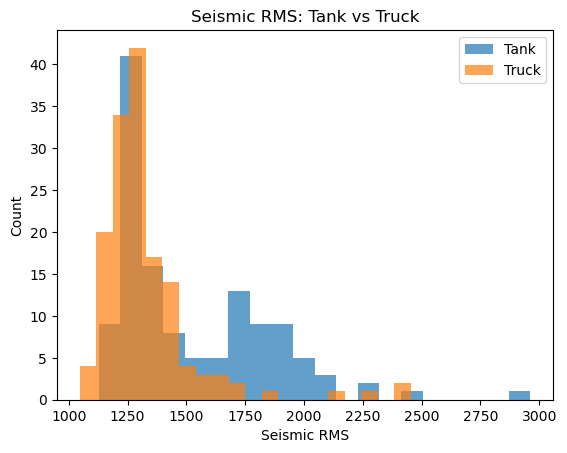

In [44]:
import matplotlib.pyplot as plt

seismic_rms = X[:, 2]   # RMS of seismic (index explanation below)

plt.figure()
plt.hist(seismic_rms[y==1], bins=20, alpha=0.7, label="Tank")
plt.hist(seismic_rms[y==0], bins=20, alpha=0.7, label="Truck")
plt.xlabel("Seismic RMS")
plt.ylabel("Count")
plt.legend()
plt.title("Seismic RMS: Tank vs Truck")
plt.show()

In [45]:
### emf absolute

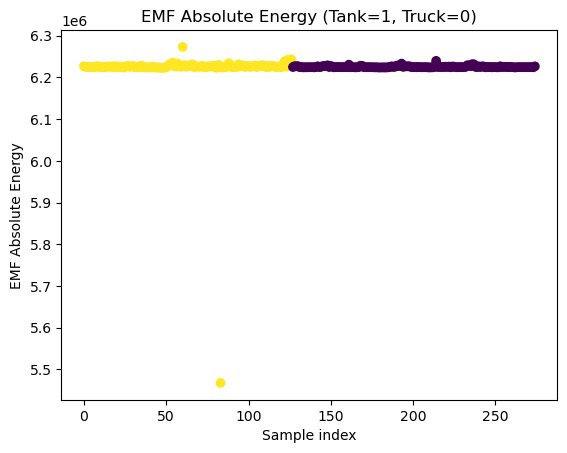

In [46]:
emf_abs_energy = X[:, 11]  # energy of EMF absolute

plt.figure()
plt.scatter(range(len(emf_abs_energy)), emf_abs_energy, c=y)
plt.xlabel("Sample index")
plt.ylabel("EMF Absolute Energy")
plt.title("EMF Absolute Energy (Tank=1, Truck=0)")
plt.show()

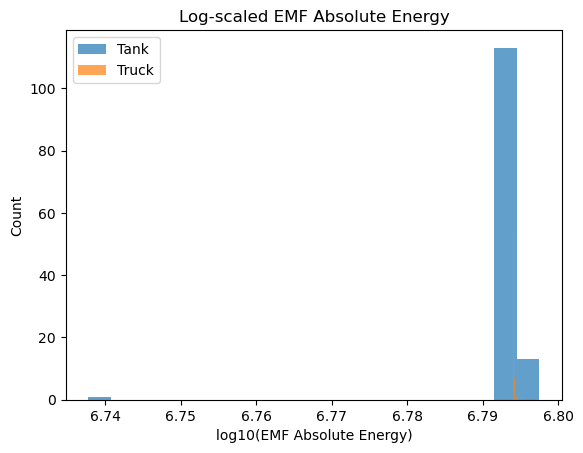

In [47]:
import numpy as np
import matplotlib.pyplot as plt

emf_abs_energy = X[:, 11]

plt.figure()
plt.hist(np.log10(emf_abs_energy[y==1]), bins=20, alpha=0.7, label="Tank")
plt.hist(np.log10(emf_abs_energy[y==0]), bins=20, alpha=0.7, label="Truck")
plt.xlabel("log10(EMF Absolute Energy)")
plt.ylabel("Count")
plt.legend()
plt.title("Log-scaled EMF Absolute Energy")
plt.show()

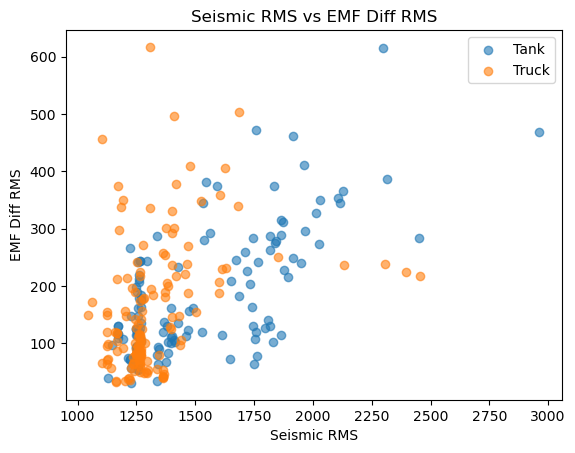

In [48]:
plt.figure()
plt.scatter(X[y==1, 2], X[y==1, 6], label="Tank", alpha=0.6)
plt.scatter(X[y==0, 2], X[y==0, 6], label="Truck", alpha=0.6)
plt.xlabel("Seismic RMS")
plt.ylabel("EMF Diff RMS")
plt.legend()
plt.title("Seismic RMS vs EMF Diff RMS")
plt.show()

In [50]:
### more featues


In [49]:
import numpy as np
from scipy.stats import kurtosis

def extract_features(signal):
    features = []

    for col in range(3):
        data = signal[:, col]

        mean = np.mean(data)
        std = np.std(data)
        rms = np.sqrt(np.mean(data**2))
        energy = np.mean(data**2)

        peak = np.max(np.abs(data))
        peak_to_rms = peak / (rms + 1e-8)

        kurt = kurtosis(data)

        features.extend([
            mean, std, rms, energy,
            peak_to_rms, kurt
        ])

    # Extra feature: ZCR for seismic only
    seismic = signal[:, 0]
    zcr = np.mean(np.diff(np.sign(seismic)) != 0)
    features.append(zcr)

    return features

In [51]:
test_feats = extract_features(all_signals[0])
print("Number of features:", len(test_feats))
print(test_feats)

Number of features: 19
[np.float64(1400.672142064373), np.float64(11.27824294993398), np.float64(1400.7175476587836), np.float64(1962009.6483192367), np.float64(1.257926698307235), np.float64(166.2596323695658), np.float64(78.33297868268973), np.float64(81.28699761607506), np.float64(112.8876943282062), np.float64(12743.631530738516), np.float64(17.36238844712279), np.float64(53.25664077476703), np.float64(2495.3960937400334), np.float64(6.548521725886478), np.float64(2495.4046861761344), np.float64(6227044.547789812), np.float64(1.041915170871032), np.float64(24.211724551294793), np.float64(0.0)]


In [52]:
import numpy as np

test_feats = np.array(test_feats)

print("Any NaN?", np.isnan(test_feats).any())
print("Any Inf?", np.isinf(test_feats).any())

Any NaN? False
Any Inf? False


In [53]:
### Compare Tank vs Truck feature values (sanity)

In [54]:
# find first tank and first truck
tank_idx = all_labels.index(1)
truck_idx = all_labels.index(0)

tank_feats = extract_features(all_signals[tank_idx])
truck_feats = extract_features(all_signals[truck_idx])

print("Tank features (first 6):", tank_feats[:6])
print("Truck features (first 6):", truck_feats[:6])

Tank features (first 6): [np.float64(1400.672142064373), np.float64(11.27824294993398), np.float64(1400.7175476587836), np.float64(1962009.6483192367), np.float64(1.257926698307235), np.float64(166.2596323695658)]
Truck features (first 6): [np.float64(1273.3844347022011), np.float64(47.21725229833527), np.float64(1274.2595447774559), np.float64(1623737.387456449), np.float64(1.7892744137775323), np.float64(125.31349990027456)]


In [55]:
X = []
y = []

for signal, label in zip(all_signals, all_labels):
    X.append(extract_features(signal))
    y.append(label)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (275, 19)
y shape: (275,)


In [56]:
np.save("X_features.npy", X)
np.save("y_labels.npy", y)

print("Features saved safely")

Features saved safely


In [57]:
## VISUALIZATION

In [58]:
# Feature Names (for reference)
feature_names = []

cols = ["Seismic", "EMF_Diff", "EMF_Abs"]
for c in cols:
    feature_names.extend([
        f"{c}_mean",
        f"{c}_std",
        f"{c}_rms",
        f"{c}_energy",
        f"{c}_peak_to_rms",
        f"{c}_kurtosis"
    ])

feature_names.append("Seismic_ZCR")

for i, name in enumerate(feature_names):
    print(i, name)

0 Seismic_mean
1 Seismic_std
2 Seismic_rms
3 Seismic_energy
4 Seismic_peak_to_rms
5 Seismic_kurtosis
6 EMF_Diff_mean
7 EMF_Diff_std
8 EMF_Diff_rms
9 EMF_Diff_energy
10 EMF_Diff_peak_to_rms
11 EMF_Diff_kurtosis
12 EMF_Abs_mean
13 EMF_Abs_std
14 EMF_Abs_rms
15 EMF_Abs_energy
16 EMF_Abs_peak_to_rms
17 EMF_Abs_kurtosis
18 Seismic_ZCR


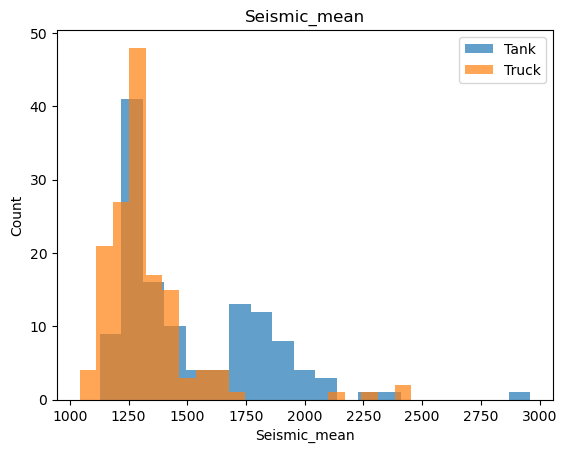

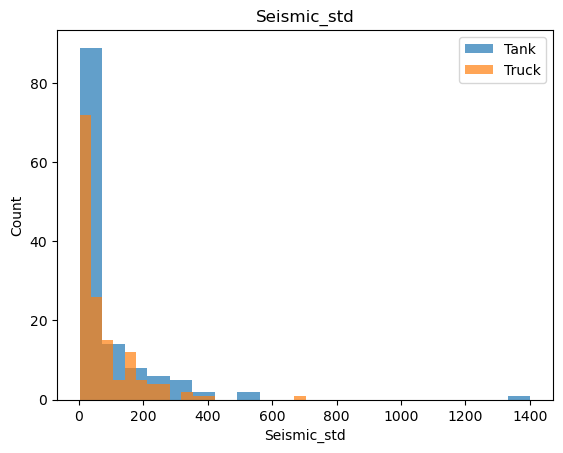

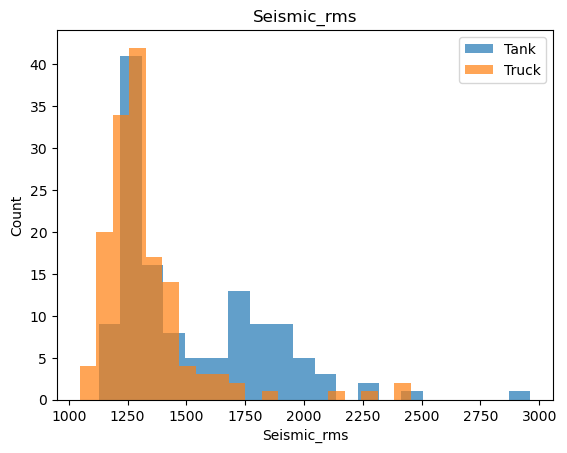

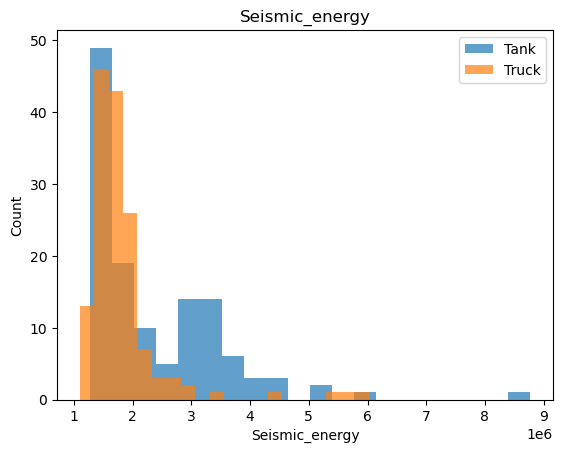

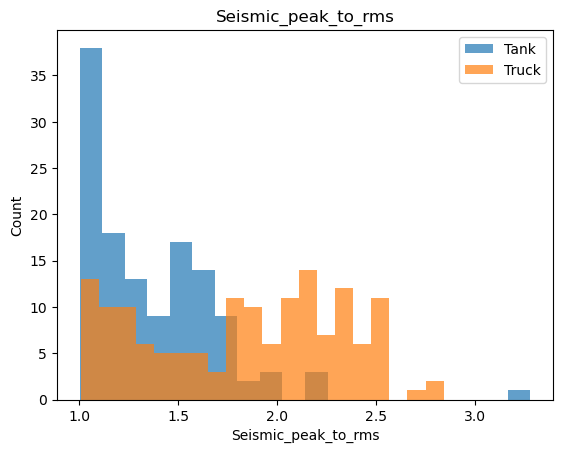

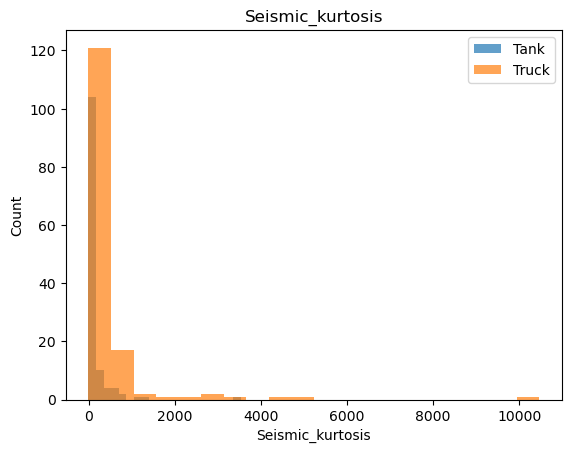

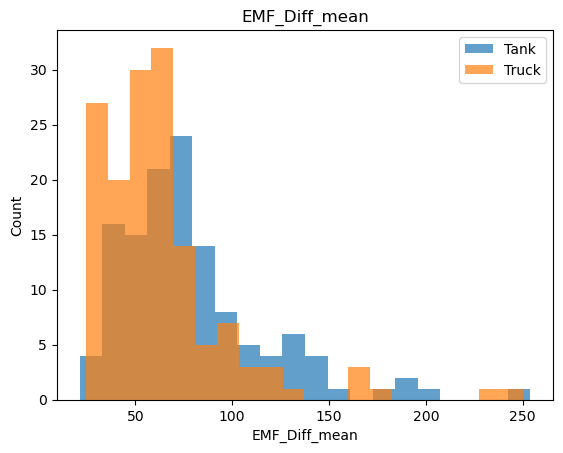

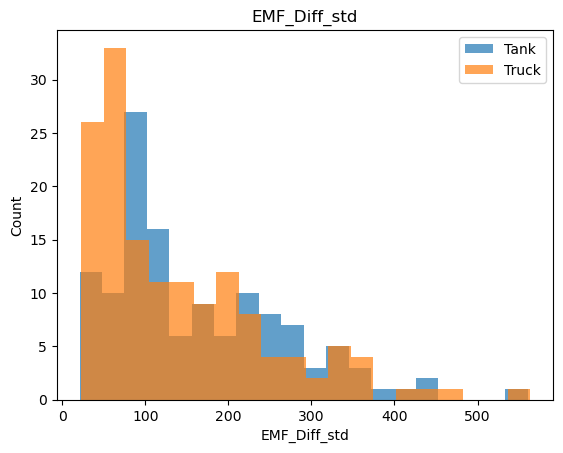

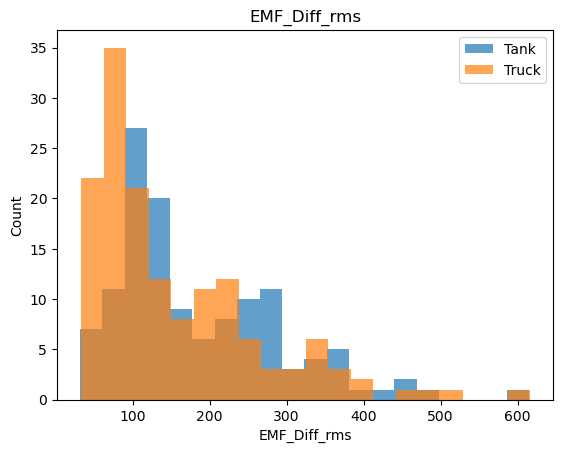

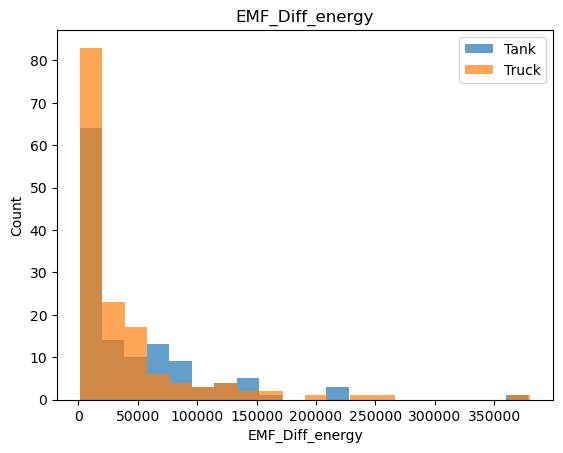

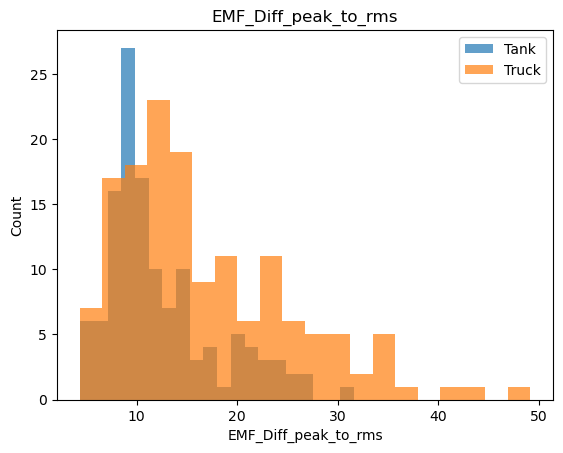

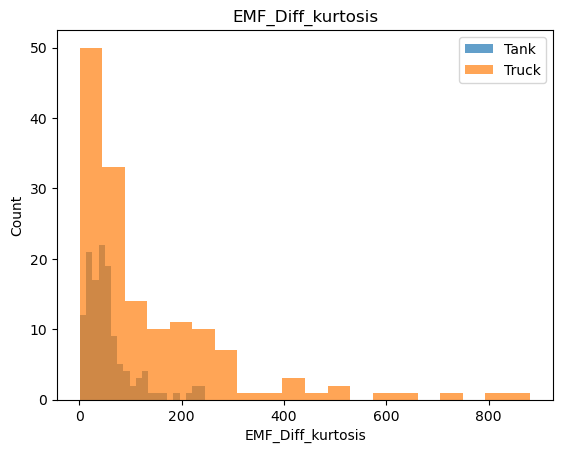

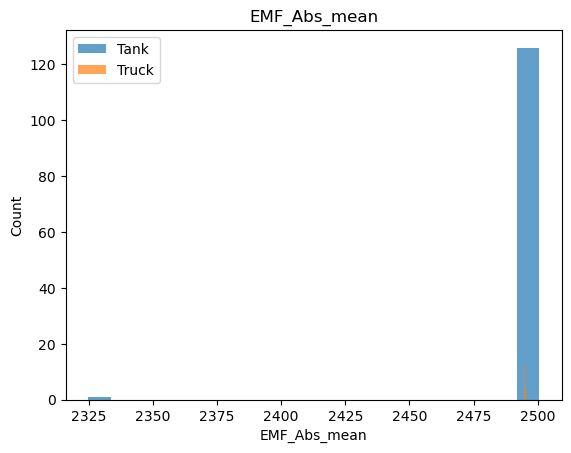

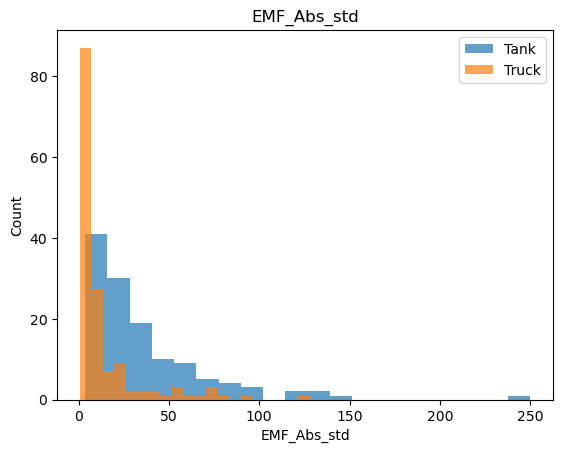

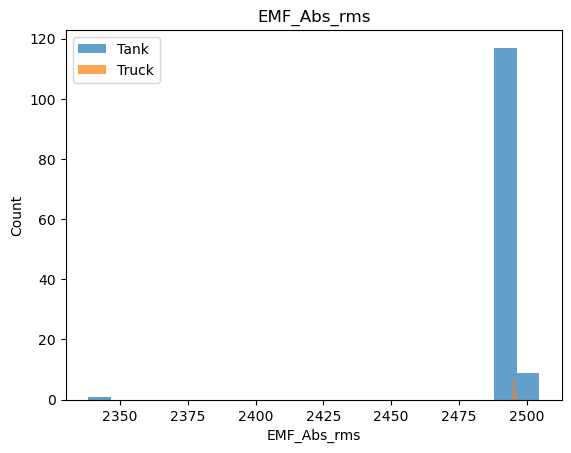

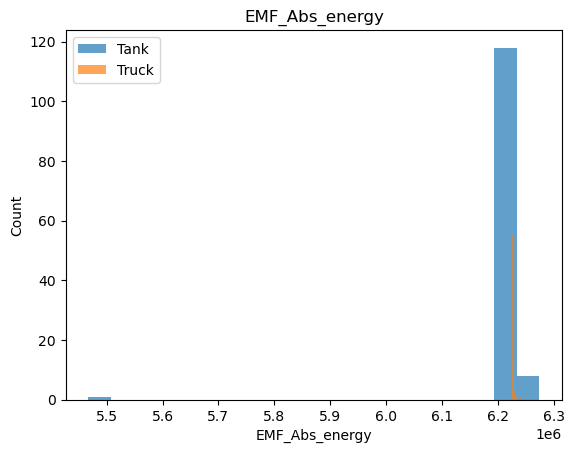

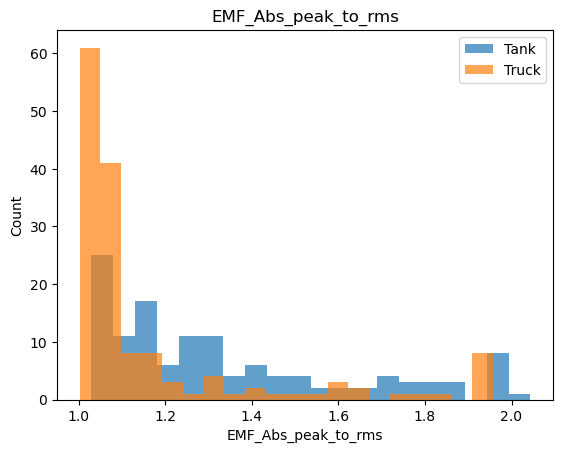

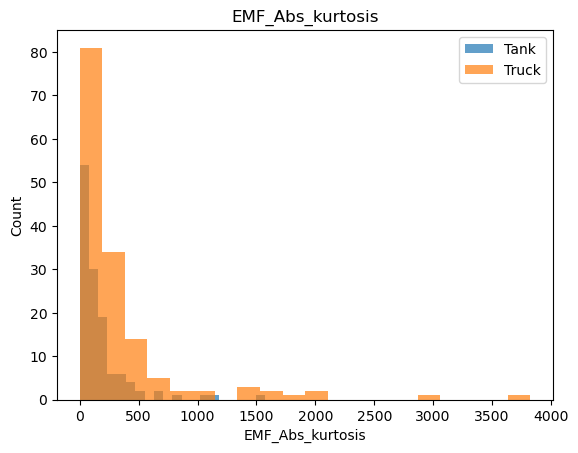

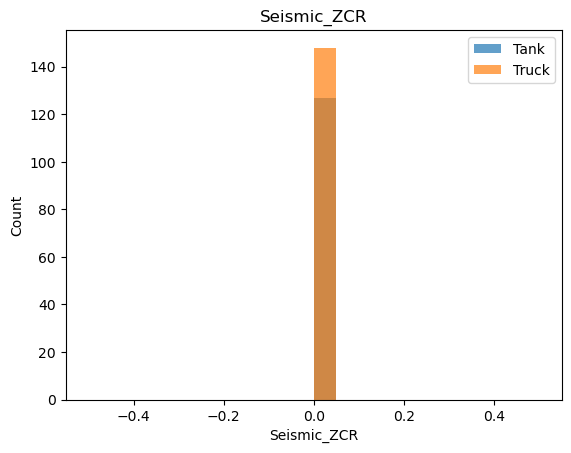

In [59]:
# Histogram of ALL Features (Tank vs Truck)
import matplotlib.pyplot as plt

for i, fname in enumerate(feature_names):
    plt.figure()
    plt.hist(X[y==1, i], bins=20, alpha=0.7, label="Tank")
    plt.hist(X[y==0, i], bins=20, alpha=0.7, label="Truck")
    plt.title(fname)
    plt.xlabel(fname)
    plt.ylabel("Count")
    plt.legend()
    plt.show()

In [60]:
# Log-Scale Histograms (Energy Features)

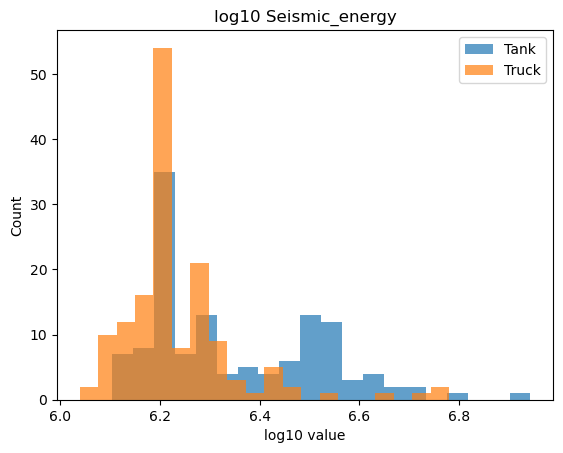

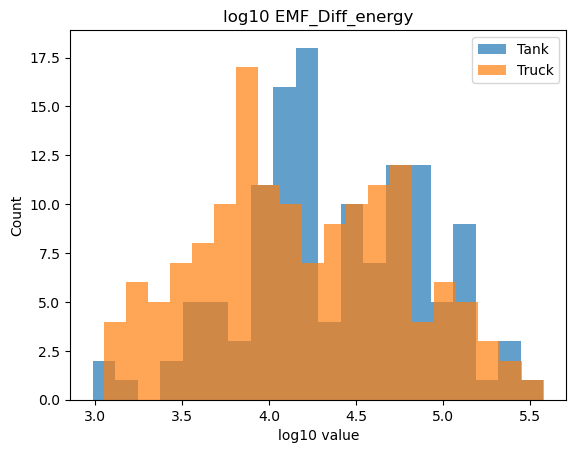

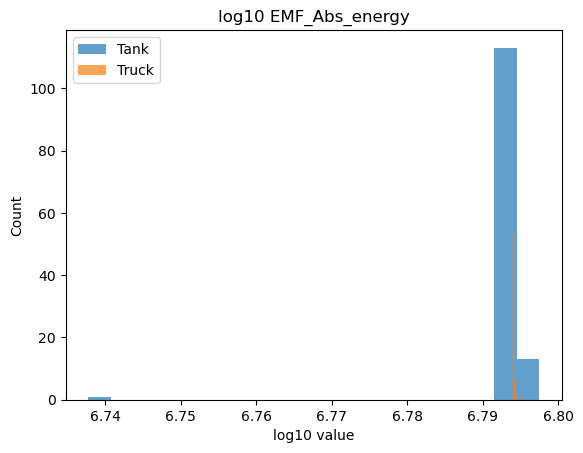

In [61]:
energy_indices = [
    feature_names.index("Seismic_energy"),
    feature_names.index("EMF_Diff_energy"),
    feature_names.index("EMF_Abs_energy")
]

for idx in energy_indices:
    plt.figure()
    plt.hist(np.log10(X[y==1, idx]), bins=20, alpha=0.7, label="Tank")
    plt.hist(np.log10(X[y==0, idx]), bins=20, alpha=0.7, label="Truck")
    plt.title("log10 " + feature_names[idx])
    plt.xlabel("log10 value")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

In [62]:
# Pairwise Scatter Plots

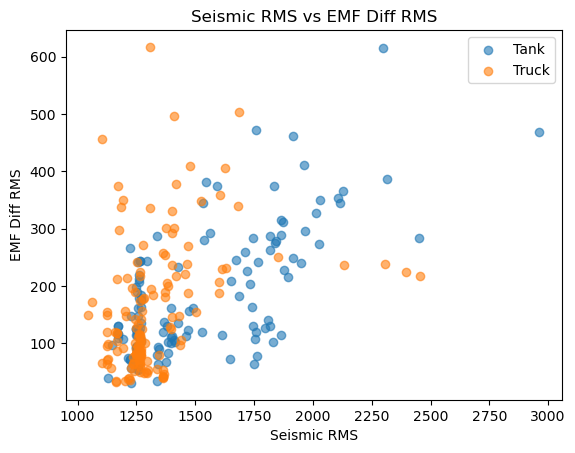

In [63]:
plt.figure()
plt.scatter(X[y==1, 2], X[y==1, 8], label="Tank", alpha=0.6)
plt.scatter(X[y==0, 2], X[y==0, 8], label="Truck", alpha=0.6)
plt.xlabel("Seismic RMS")
plt.ylabel("EMF Diff RMS")
plt.legend()
plt.title("Seismic RMS vs EMF Diff RMS")
plt.show()

In [64]:
# Seismic Energy vs EMF Abs Energy (log scale)

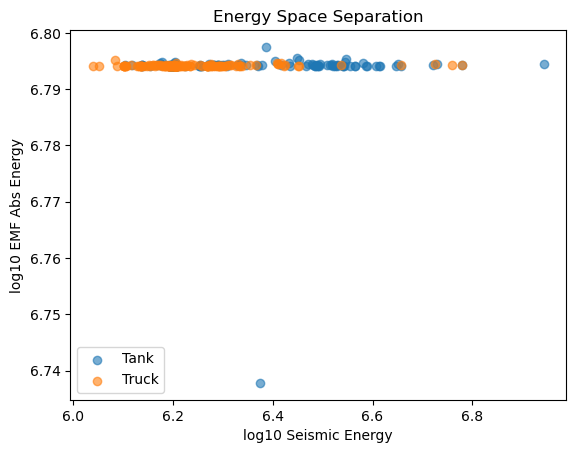

In [65]:
plt.figure()
plt.scatter(
    np.log10(X[y==1, 3]),
    np.log10(X[y==1, 15]),
    label="Tank",
    alpha=0.6
)
plt.scatter(
    np.log10(X[y==0, 3]),
    np.log10(X[y==0, 15]),
    label="Truck",
    alpha=0.6
)
plt.xlabel("log10 Seismic Energy")
plt.ylabel("log10 EMF Abs Energy")
plt.legend()
plt.title("Energy Space Separation")
plt.show()

In [66]:
# Boxplots (VERY GOOD for reports)

C:\Users\Jaykumarintern\AppData\Local\Temp\ipykernel_10780\213556232.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


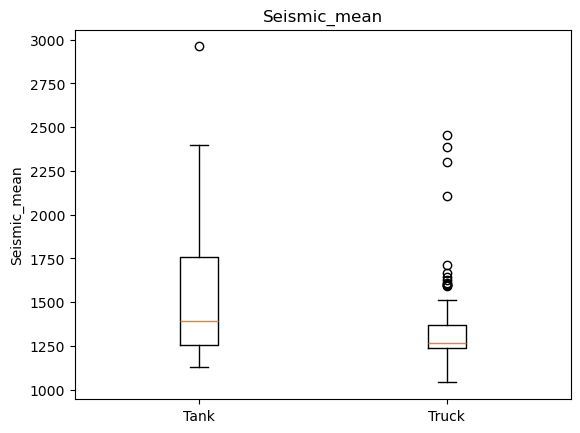

C:\Users\Jaykumarintern\AppData\Local\Temp\ipykernel_10780\213556232.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


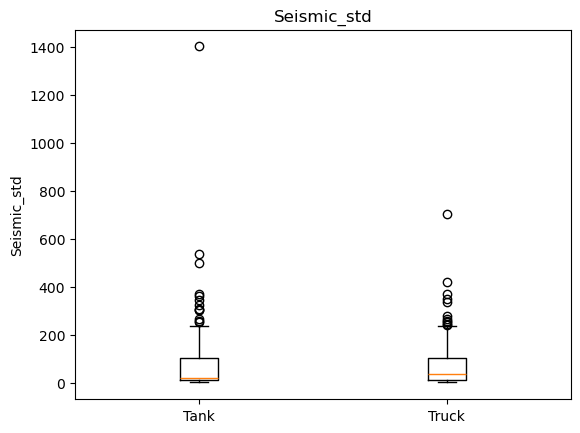

C:\Users\Jaykumarintern\AppData\Local\Temp\ipykernel_10780\213556232.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


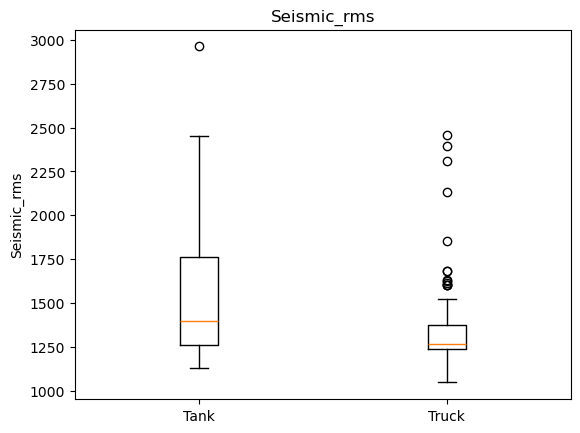

C:\Users\Jaykumarintern\AppData\Local\Temp\ipykernel_10780\213556232.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


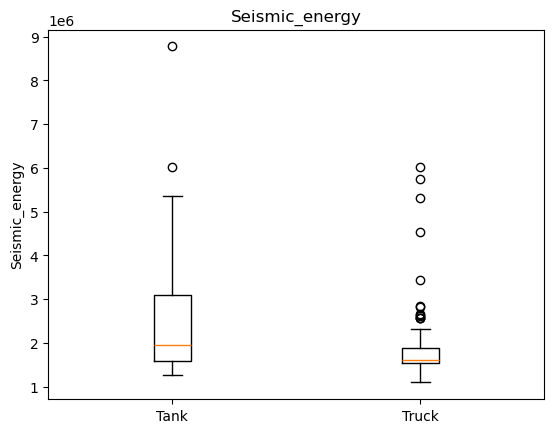

C:\Users\Jaykumarintern\AppData\Local\Temp\ipykernel_10780\213556232.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


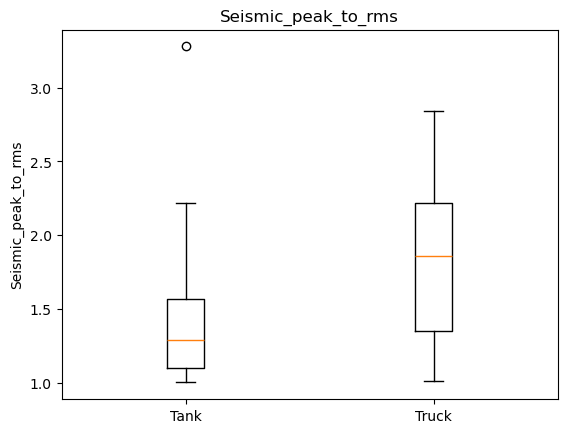

C:\Users\Jaykumarintern\AppData\Local\Temp\ipykernel_10780\213556232.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


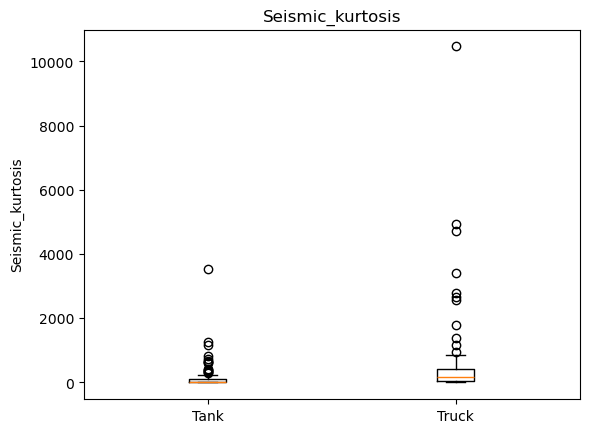

C:\Users\Jaykumarintern\AppData\Local\Temp\ipykernel_10780\213556232.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


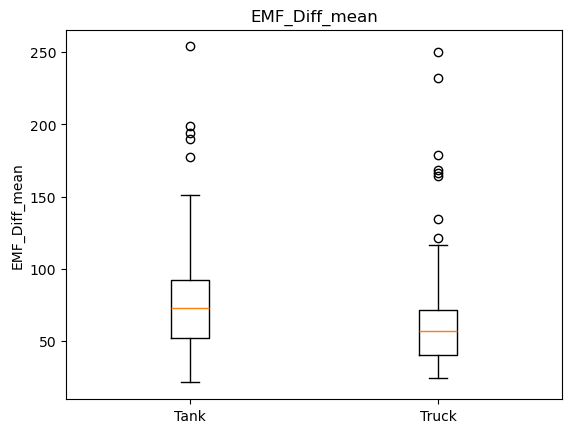

C:\Users\Jaykumarintern\AppData\Local\Temp\ipykernel_10780\213556232.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


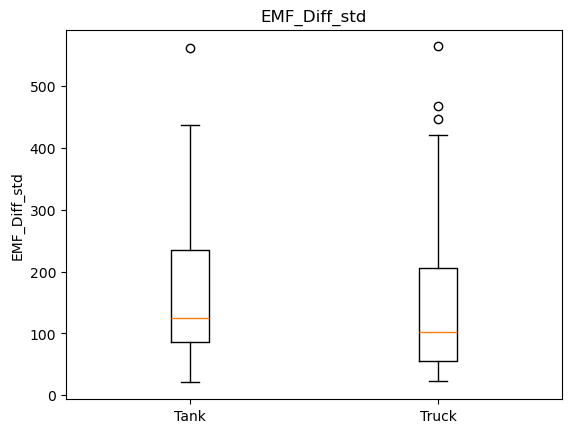

C:\Users\Jaykumarintern\AppData\Local\Temp\ipykernel_10780\213556232.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


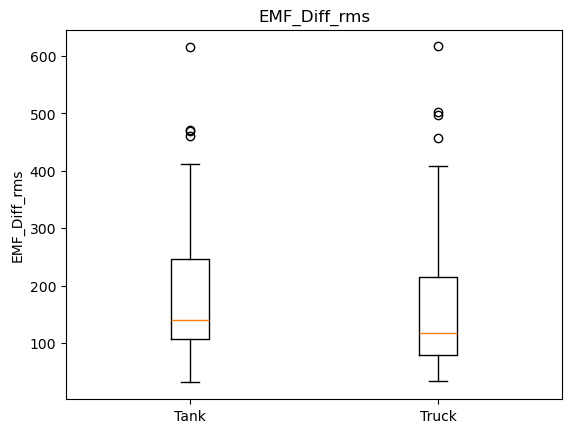

C:\Users\Jaykumarintern\AppData\Local\Temp\ipykernel_10780\213556232.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


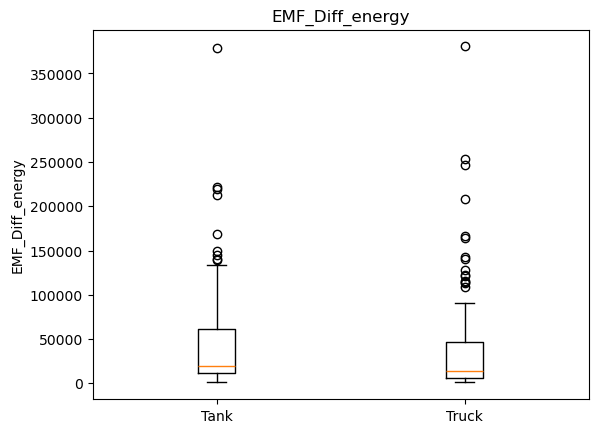

C:\Users\Jaykumarintern\AppData\Local\Temp\ipykernel_10780\213556232.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


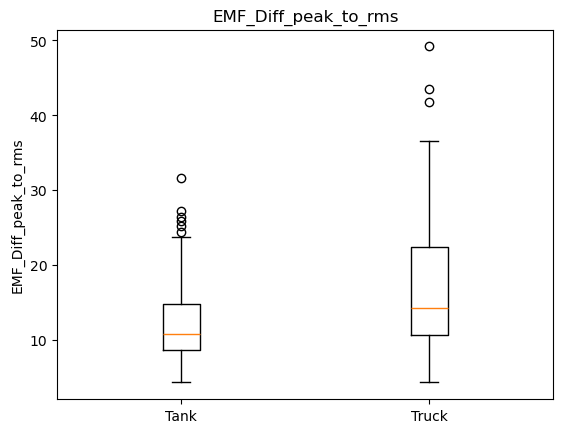

C:\Users\Jaykumarintern\AppData\Local\Temp\ipykernel_10780\213556232.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


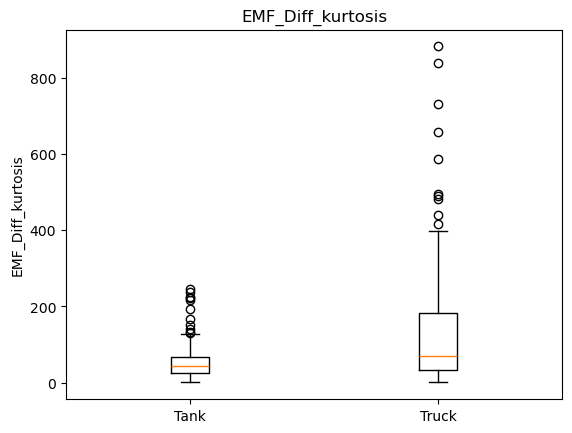

C:\Users\Jaykumarintern\AppData\Local\Temp\ipykernel_10780\213556232.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


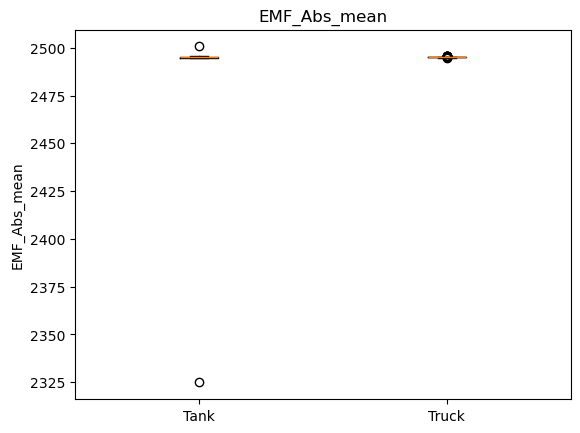

C:\Users\Jaykumarintern\AppData\Local\Temp\ipykernel_10780\213556232.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


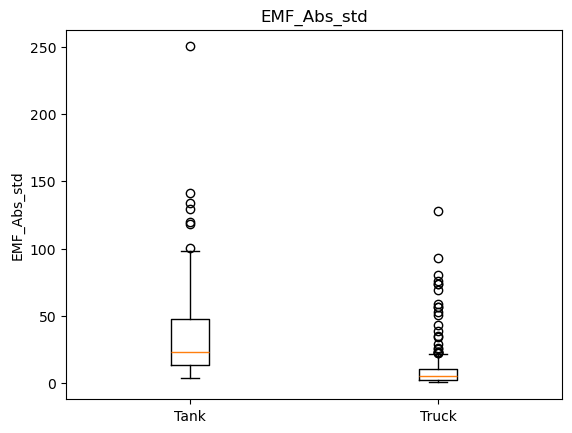

C:\Users\Jaykumarintern\AppData\Local\Temp\ipykernel_10780\213556232.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


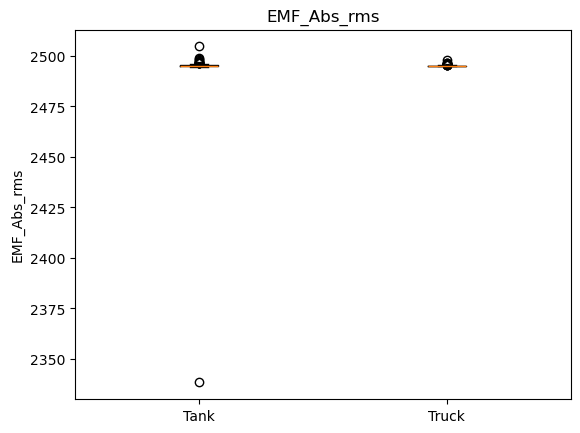

C:\Users\Jaykumarintern\AppData\Local\Temp\ipykernel_10780\213556232.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


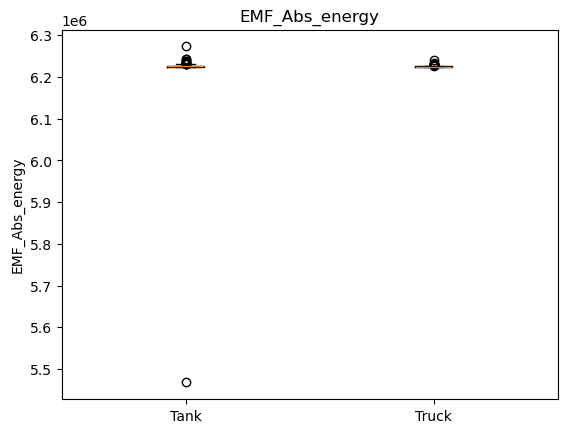

C:\Users\Jaykumarintern\AppData\Local\Temp\ipykernel_10780\213556232.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


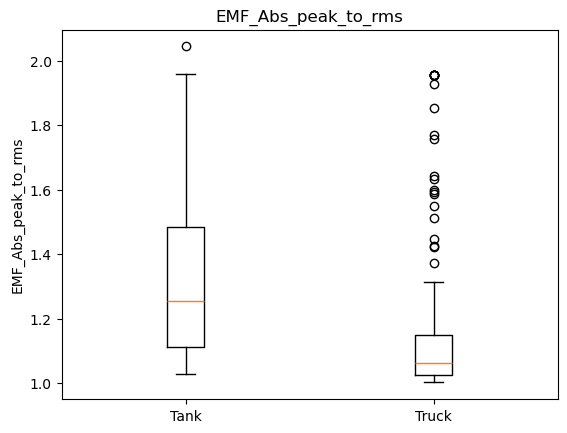

C:\Users\Jaykumarintern\AppData\Local\Temp\ipykernel_10780\213556232.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


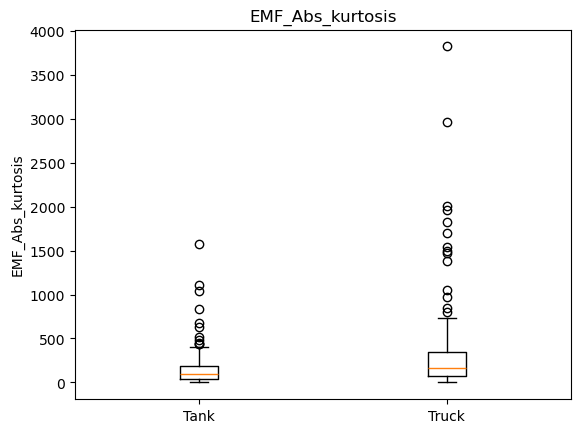

C:\Users\Jaykumarintern\AppData\Local\Temp\ipykernel_10780\213556232.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


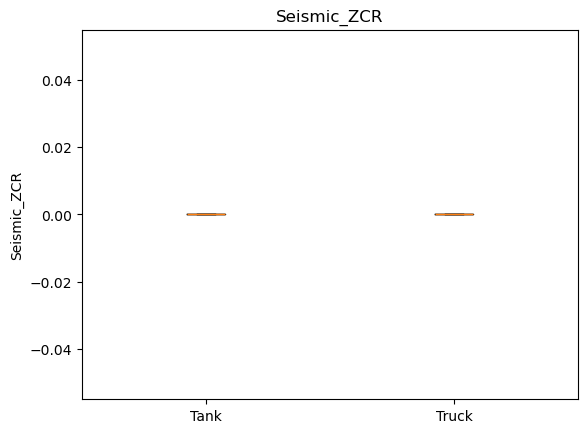

In [68]:
for i, fname in enumerate(feature_names):
    plt.figure()
    plt.boxplot(
        [X[y==1, i], X[y==0, i]],
        labels=["Tank", "Truck"]
    )
    plt.title(fname)
    plt.ylabel(fname)
    plt.show()

C:\Users\Jaykumarintern\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Jaykumarintern\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


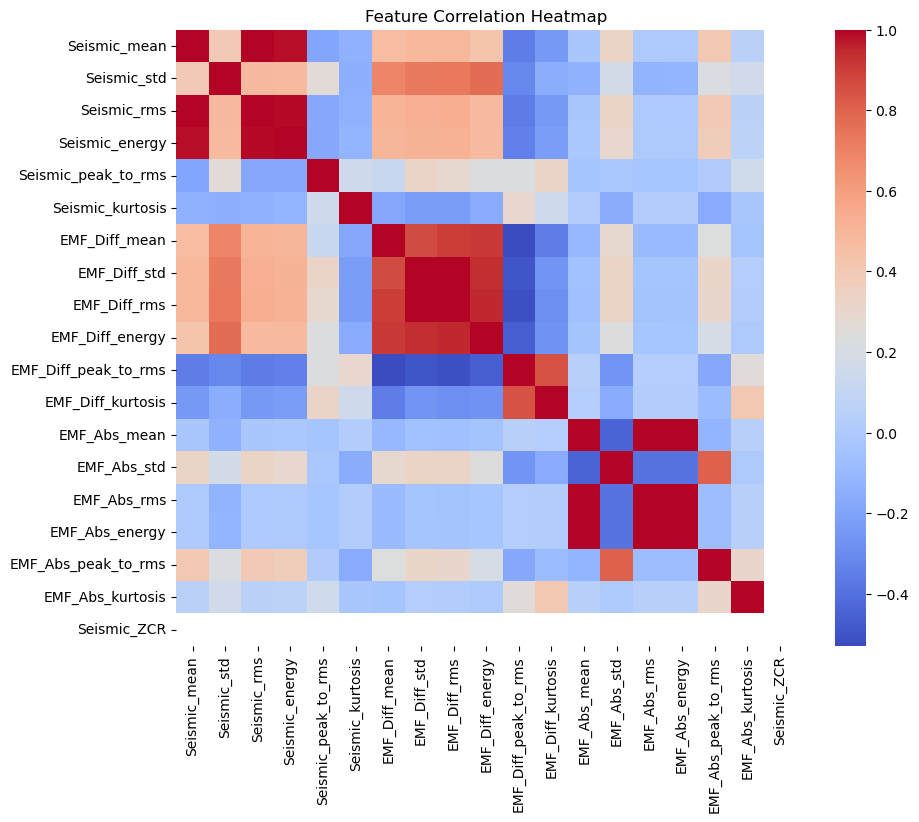

In [69]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(
    np.corrcoef(X.T),
    xticklabels=feature_names,
    yticklabels=feature_names,
    cmap="coolwarm"
)
plt.title("Feature Correlation Heatmap")
plt.show()

In [70]:
### Freeze features

In [72]:
np.save("X_features.npy", X)
np.save("y_labels.npy", y)

## Training

In [73]:
# Load FINAL frozen features
import numpy as np

X = np.load("X_features.npy")
y = np.load("y_labels.npy")

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (275, 19)
y shape: (275,)


In [74]:
# Train / Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 80–20 split (standard)
    random_state=42,
    stratify=y          # keeps tank/truck ratio same
)

print("Train samples:", X_train.shape[0])
print("Test samples :", X_test.shape[0])

Train samples: 220
Test samples : 55


In [75]:
# Train Random Forest
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,        # stable, not overkill
    max_depth=None,         # let trees grow
    min_samples_leaf=2,     # reduces overfitting
    random_state=42,
    n_jobs=-1               # use all CPU cores
)

model.fit(X_train, y_train)

print("Model training completed")

Model training completed


In [76]:
# Evaluate
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8727272727272727

Confusion Matrix:
 [[26  4]
 [ 3 22]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.88        30
           1       0.85      0.88      0.86        25

    accuracy                           0.87        55
   macro avg       0.87      0.87      0.87        55
weighted avg       0.87      0.87      0.87        55



In [77]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV F1 score:", grid.best_score_)

Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 200}
Best CV F1 score: 0.895063440644836


In [78]:
# gridsearch
best_model = grid.best_estimator_

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Test Accuracy: 0.8727272727272727

Confusion Matrix:
 [[26  4]
 [ 3 22]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.88        30
           1       0.85      0.88      0.86        25

    accuracy                           0.87        55
   macro avg       0.87      0.87      0.87        55
weighted avg       0.87      0.87      0.87        55



### Save the FINAL model (very important)

In [79]:
import joblib
joblib.dump(model, "final_tank_vs_truck_model.pkl")
print("Final model saved")

Final model saved


### Demonstrate SINGLE-FILE prediction

In [80]:
def predict_vehicle(file_path):
    signal = read_vehicle_file(file_path)
    features = extract_features(signal)
    features = np.array(features).reshape(1, -1)
    pred = model.predict(features)[0]
    return "TANK" if pred == 1 else "NON-TANK"

In [82]:
# Testing
predict_vehicle(
    "Data/Tank/T72 tank/Actual Misdistance 30cm T72.txt"
)

'TANK'

In [83]:
# Testing
predict_vehicle(
    "Data/Truck/AM50 Patiala Automobile 50Ton Bridge truck/AM50 1 run 40km.txt"
)

'NON-TANK'

In [85]:
# Testing
predict_vehicle(
    "Data/jeep/pokeland 40m dist.txt"
)

'TANK'

In [86]:
import joblib
joblib.dump(model, "final_tank_vs_truck_model.pkl")
print("Final model saved")

Final model saved
